In [ ]:
# 查看当前挂载的数据集目录, 该目录下的变更重启环境后会自动还原
# View dataset directory. 
# This directory will be recovered automatically after resetting environment. 
!ls /home/aistudio/data

datasets  models


In [ ]:
# 查看工作区文件，该目录下除data目录外的变更将会持久保存。请及时清理不必要的文件，避免加载过慢。
# View personal work directory. 
# All changes, except /data, under this directory will be kept even after reset. 
# Please clean unnecessary files in time to speed up environment loading. 
!ls /home/aistudio

data  external-libraries  main.ipynb  work


In [ ]:
# 如果需要进行持久化安装, 需要使用持久化路径, 如下方代码示例:
# If a persistence installation is required, 
# you need to use the persistence path as the following: 
!mkdir /home/aistudio/external-libraries
!pip install beautifulsoup4

mkdir: cannot create directory '/home/aistudio/external-libraries': File exists
Looking in indexes: http://mirrors.baidubce.com/pypi/simple/


In [ ]:
# 同时添加如下代码, 这样每次环境(kernel)启动的时候只要运行下方代码即可: 
# Also add the following code, 
# so that every time the environment (kernel) starts, 
# just run the following code: 
import sys 
sys.path.append('/home/aistudio/external-libraries')

In [ ]:
!mkdir -p work/rock_dataset/granite work/rock_dataset/sandstone work/rock_dataset/limestone


请点击[此处](https://ai.baidu.com/docs#/AIStudio_Project_Notebook/a38e5576)查看本环境基本用法.  <br>
Please click [here ](https://ai.baidu.com/docs#/AIStudio_Project_Notebook/a38e5576) for more detailed instructions. 

In [ ]:
import paddle
from paddle.vision import transforms
from paddle.vision.models import resnet18
from paddle.io import Dataset, DataLoader
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# 解决AI Studio中文显示
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False

print("飞桨版本：", paddle.__version__)


飞桨版本： 3.3.0


In [ ]:
random.seed(42)
data_root = "work/rock_dataset"
class_names = ["granite", "sandstone", "limestone"]
train_list = []
val_list = []

for label_idx, cls in enumerate(class_names):
    img_dir = os.path.join(data_root, cls)
    img_files = [os.path.join(img_dir, f) for f in os.listdir(img_dir)
                 if f.endswith(('jpg','png','jpeg'))]
    random.shuffle(img_files)
    # 80%训练，20%验证
    split = int(len(img_files)*0.8)
    for p in img_files[:split]:
        train_list.append(f"{p}\t{label_idx}")
    for p in img_files[split:]:
        val_list.append(f"{p}\t{label_idx}")

# 保存列表文件
with open("work/train.txt","w",encoding="utf-8") as f:
    f.write("\n".join(train_list))
with open("work/val.txt","w",encoding="utf-8") as f:
    f.write("\n".join(val_list))

print(f"训练集数量：{len(train_list)}，验证集数量：{len(val_list)}")


训练集数量：45，验证集数量：13


In [ ]:
# 图像预处理
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

class RockDataset(Dataset):
    def __init__(self, txt_path, transform):
        super().__init__()
        self.transform = transform
        self.data = []
        with open(txt_path,"r",encoding="utf-8") as f:
            for line in f.readlines():
                img_path, label = line.strip().split("\t")
                self.data.append((img_path, int(label)))

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.data)

train_ds = RockDataset("work/train.txt", train_transform)
val_ds = RockDataset("work/val.txt", val_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8)



In [63]:
# 模型：resnet18，3分类（3种岩石）
model = resnet18(num_classes=3, pretrained=True)

# 优化器、损失函数
opt = paddle.optimizer.Adam(learning_rate=0.001, parameters=model.parameters())
loss_fn = paddle.nn.CrossEntropyLoss()

# 训练10轮
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    # 训练
    for img, label in train_loader:
        out = model(img)
        loss = loss_fn(out, label)
        loss.backward()
        opt.step()
        opt.clear_grad()
        total_loss += loss.numpy()
    
    # 验证
    model.eval()
    acc_sum = 0
    total_num = 0
    with paddle.no_grad():
        for img, label in val_loader:
            out = model(img)
            pred = paddle.argmax(out, axis=1)
            acc_sum += paddle.sum(pred == label).numpy()
            total_num += img.shape[0]
    val_acc = acc_sum / total_num
    
    print(f"Epoch {epoch+1}, train_loss:{total_loss:.3f}, val_acc:{val_acc:.3f}")

# 保存模型
paddle.save(model.state_dict(), "work/rock_model.pdparams")
print("模型保存完成")


[2026-09-16 14:15:59,474] [    INFO] download.py:116 - unique_endpoints {''}
[2026-09-16 14:15:59,474] [    INFO] download.py:248 - File /home/aistudio/.cache/paddle/hapi/weights/resnet18.pdparams md5 checking...
[2026-09-16 14:15:59,626] [    INFO] download.py:155 - Found /home/aistudio/.cache/paddle/hapi/weights/resnet18.pdparams


Epoch 1, train_loss:11.369, val_acc:0.308
Epoch 2, train_loss:19.484, val_acc:0.538
Epoch 3, train_loss:10.090, val_acc:0.462
Epoch 4, train_loss:6.197, val_acc:0.538


KeyboardInterrupt: 

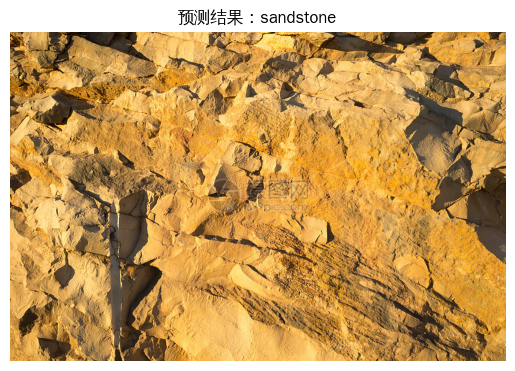

'sandstone'

In [76]:
def predict(img_path):
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
    ])
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0)
    model.eval()
    out = model(img_tensor)
    pred_idx = paddle.argmax(out).numpy()  # 删掉后面的 [0]
    rock_name = class_names[pred_idx]
    plt.imshow(img)
    plt.title(f"预测结果：{rock_name}")
    plt.axis('off')
    plt.show()
    return rock_name

# 选用sandstone里真实存在的图片
predict("work/rock_dataset/sandstone/1100.jpg_wh860.jpg")


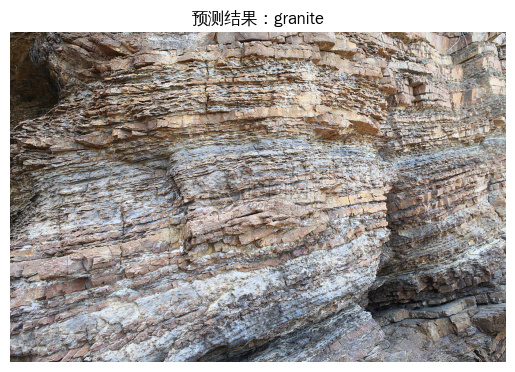

'granite'

In [68]:
predict("work/rock_dataset/sandstone/5756.jpg_wh860.jpg")


In [80]:
import paddle
# 定义输入规格：1张图片，3通道RGB，224×224
input_spec = paddle.static.InputSpec(shape=[1, 3, 224, 224], dtype='float32', name='img')
paddle.jit.save(model, "work/rock_infer_model", input_spec=[input_spec])
print("✅部署模型导出成功，保存在 work/rock_infer_model")



✅部署模型导出成功，保存在 work/rock_infer_model


W0916 14:20:39.117177   103 eager_utils.cc:3584] Paddle static graph(PIR) not support input out tensor for now!!!!!
